## Inference Notebook

#### 1. Setup and Imports

In [ ]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.getcwd())
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'src')):
    PROJECT_ROOT = os.path.abspath('..')

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from src.dataset import get_dataloaders
from src.models import TinyCNN, MediumCNN, DeepCNN, VGGStyleCNN, CustomResNet, TransferResNet18
from src.utils import load_wandb_results, EMOTION_LABELS
import wandb

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
wandb.login()
print('Ready')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\l.chitishvili\_netrc.


Using device: cuda


wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ready


#### 2. Best Model

In [2]:
import json

all_arch_results = []

result_files = {
    'tiny':     ('tinycnn_results.json',    TinyCNN,          {'dropout': 0.0}),
    'medium':   ('mediumcnn_results.json',  MediumCNN,        {'dropout': 0.25}),
    'deep':     ('deepcnn_results.json',    DeepCNN,          {'dropout': 0.5}),
    'vgg':      ('vgg_results.json',        VGGStyleCNN,      {'dropout': 0.5}),
    'resnet':   ('resnet_results.json',     CustomResNet,     {'dropout': 0.5}),
    'transfer': ('transfer_results.json',   TransferResNet18, {'mode': 'finetune'}),
}

for arch, (filename, model_class, model_kwargs) in result_files.items():
    path = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.exists(path):
        with open(path, 'r') as f:
            results = json.load(f)
        best = max(results, key=lambda x: x['best_val_acc'])
        all_arch_results.append({
            'arch': arch,
            'run': best['run'],
            'best_val_acc': best['best_val_acc'],
            'model_class': model_class,
            'model_kwargs': model_kwargs
        })
        print(f'{arch}: best={best["run"]} | val_acc={best["best_val_acc"]:.4f}')
    else:
        print(f'{arch}: no results file found')

all_arch_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model_class', 'model_kwargs']}
                              for r in all_arch_results])
print('\n--- All Architecture Comparison ---')
print(all_arch_df.sort_values('best_val_acc', ascending=False).to_string(index=False))

best_overall = max(all_arch_results, key=lambda x: x['best_val_acc'])
print(f'\nBest overall: {best_overall["arch"]} — {best_overall["run"]} — val_acc={best_overall["best_val_acc"]:.4f}')


tiny: best=tiny_adam_0.001_bs64_light_do0 | val_acc=0.5566
medium: best=medium_adam_0.001_bs64_light_do0.25 | val_acc=0.6169
deep: best=deep_adam_0.001_bs32_noaug_do0_overfit | val_acc=0.6243
vgg: best=vgg_adam_0.0003_bs64_strong_do0.25_wd1e-4 | val_acc=0.6546
resnet: best=resnet_adam_0.001_bs32_light_do0.5 | val_acc=0.6327
transfer: best=transfer_finetune_adam_1e-4_bs64_strong_sched | val_acc=0.6327

--- All Architecture Comparison ---
    arch                                           run  best_val_acc
     vgg     vgg_adam_0.0003_bs64_strong_do0.25_wd1e-4      0.654650
  resnet            resnet_adam_0.001_bs32_light_do0.5      0.632706
transfer transfer_finetune_adam_1e-4_bs64_strong_sched      0.632706
    deep        deep_adam_0.001_bs32_noaug_do0_overfit      0.624347
  medium           medium_adam_0.001_bs64_light_do0.25      0.616858
    tiny                tiny_adam_0.001_bs64_light_do0      0.556600

Best overall: vgg — vgg_adam_0.0003_bs64_strong_do0.25_wd1e-4 — val_acc=0.6

#### 3. Load Best Model

In [3]:
best_run_name   = best_overall['run']
model_class     = best_overall['model_class']
model_kwargs    = best_overall['model_kwargs']
checkpoint_path = os.path.join(CHECKPOINT_DIR, f'{best_run_name}_best.pt')

print(f'Loading: {best_run_name}')
print(f'Checkpoint: {checkpoint_path}')
print(f'Exists: {os.path.exists(checkpoint_path)}')

if 'dropout' in model_kwargs and model_kwargs['dropout'] == 0.25:
    if 'do0.5' in best_run_name:
        model_kwargs['dropout'] = 0.5
    elif 'do0' in best_run_name and 'do0.25' not in best_run_name:
        model_kwargs['dropout'] = 0.0

model = model_class(**model_kwargs).to(DEVICE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()
print(f'Model loaded successfully')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')


Loading: vgg_adam_0.0003_bs64_strong_do0.25_wd1e-4
Checkpoint: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints\vgg_adam_0.0003_bs64_strong_do0.25_wd1e-4_best.pt
Exists: True
Model loaded successfully
Total parameters: 11,110,855


#### 4. Load Test Data

In [4]:
_, _, test_loader = get_dataloaders(
    data_dir=DATA_DIR,
    aug_mode='none',
    batch_size=64
)

print(f'Test batches: {len(test_loader)}')
print(f'Approx test samples: {len(test_loader) * 64}')


Test batches: 113
Approx test samples: 7232


#### 5. Generate Predicitions

In [5]:
all_predictions = []

model.eval()
with torch.no_grad():
    for batch_idx, images in enumerate(tqdm(test_loader, desc='Generating predictions')):
        if isinstance(images, (list, tuple)):
            images = images[0]
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_predictions.extend(preds.tolist())

print(f'Total predictions: {len(all_predictions)}')
print(f'Prediction distribution:')
for emotion_id, emotion_name in enumerate(['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']):
    count = all_predictions.count(emotion_id)
    print(f'  {emotion_name}: {count} ({count/len(all_predictions)*100:.1f}%)')


Generating predictions: 100%|██████████| 113/113 [00:03<00:00, 35.86it/s]

Total predictions: 7178
Prediction distribution:
  Angry: 1105 (15.4%)
  Disgust: 38 (0.5%)
  Fear: 633 (8.8%)
  Happy: 1835 (25.6%)
  Sad: 1473 (20.5%)
  Surprise: 725 (10.1%)
  Neutral: 1369 (19.1%)


#### 6. Submission

In [6]:
import os

os.makedirs(os.path.join(PROJECT_ROOT, 'submissions'), exist_ok=True)

submission_df = pd.DataFrame({
    'id': range(len(all_predictions)),
    'emotion': all_predictions
})

submission_path = os.path.join(PROJECT_ROOT, 'submissions', 'submission.csv')
submission_df.to_csv(submission_path, index=False)

print(f'Submission saved to: {submission_path}')
print(f'Shape: {submission_df.shape}')
print(submission_df.head(10))


Submission saved to: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\submissions\submission.csv
Shape: (7178, 2)
   id  emotion
0   0        6
1   1        0
2   2        0
3   3        6
4   4        3
5   5        3
6   6        4
7   7        4
8   8        4
9   9        6


#### 7. Sample

Test CSV rows: 7178
Submission rows: 7178
Match: True


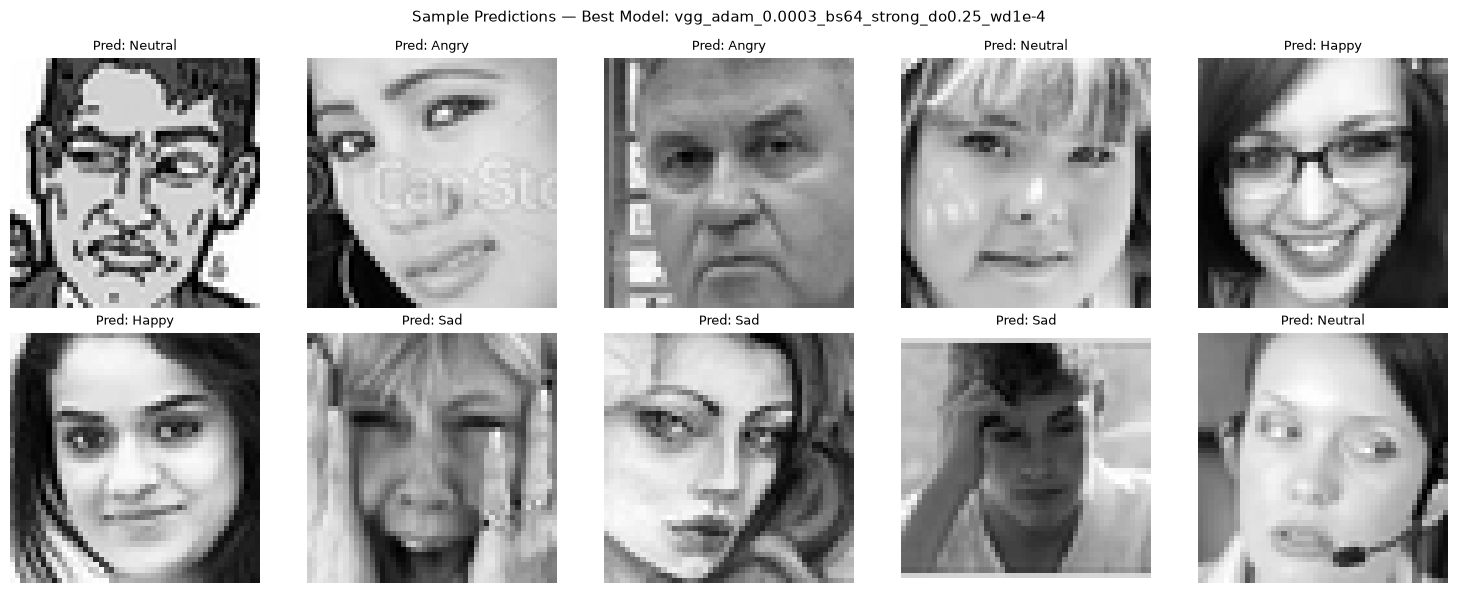


Submission file ready at: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\submissions\submission.csv
Upload this file to Kaggle competition page


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

test_csv = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f'Test CSV rows: {len(test_csv)}')
print(f'Submission rows: {len(submission_df)}')
print(f'Match: {len(test_csv) == len(submission_df)}')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
EMOTION_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

for idx, ax in enumerate(axes.flat):
    pixel_string = test_csv.iloc[idx]['pixels']
    pixel_array = np.array(pixel_string.split(), dtype=np.uint8).reshape(48, 48)
    predicted_emotion = EMOTION_NAMES[all_predictions[idx]]
    ax.imshow(pixel_array, cmap='gray')
    ax.set_title(f'Pred: {predicted_emotion}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Sample Predictions — Best Model: {best_run_name}', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'submissions', 'sample_predictions.png'), dpi=150)
plt.show()

print(f'\nSubmission file ready at: {submission_path}')
print('Upload this file to Kaggle competition page')
